# Warm-up: language models on real 10-K text

**AI for Economics and Finance · Torino, 26 August 2026 · Day 3 tutorial, part 1 (≈25 min)**

Everything from this morning's Lecture 1, on a corpus you would actually use: the *Risk Factors* section (Item 1A) of 150 annual reports filed in 2020.

1. Text → tokens → counts (and Zipf's law)
2. An n-gram language model, its perplexity, and its samples
3. What GPT-2 says about a 10-K sentence, token by token
4. The rookie mistake: raw BERT embeddings all look alike, and two fixes

Run cells top to bottom (`Shift+Enter`). No GPU needed; the two models used (GPT-2 small, BERT-base) download once (~1 GB).

In [1]:
import re, math, random, collections, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
random.seed(0); np.random.seed(0)

df = pd.read_csv("data/risk_factors_2020.csv.gz")
print(df.shape, "filings")
print(df.section_1A.iloc[0][:600])

(150, 3) filings
Item 1A. Risk Factors.
Our business faces many risks. Past experience may not be indicative of future performance, and as noted elsewhere in this Annual Report on Form 10-K, we have included forward-looking statements about our business, plans and prospects that are subject to change. Forward-looking statements are particularly located in, but not limited to, the sections “Business” and “Management’s Discussion and Analysis of Financial Condition and Results of Operations.” In addition to the other risks or uncertainties contained in this Annual Report, the risks described below may affect our


## 1. Text → tokens → counts

A document is a string. To compute with it we need units. Here: lower-cased words, split on whitespace and punctuation (a *word-level* tokenizer; GPT-2 and BERT use *subword* tokenizers, which we meet in section 3).

In [2]:
def sentences(text):
    text = re.sub(r"\s+", " ", text)
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+(?=[A-Z])", text) if len(s.split()) >= 6]

def tokenize(s):
    return re.findall(r"[a-z]+|\d+|[^\sa-z\d]", s.lower())

sents = [s for doc in df.section_1A for s in sentences(doc)]
random.shuffle(sents)
n_test = 3000
train_sents, test_sents = sents[n_test:], sents[:n_test]
train_tok = [tokenize(s) for s in train_sents]
test_tok  = [tokenize(s) for s in test_sents]
print(f"{len(sents):,} sentences; {sum(map(len, train_tok)):,} training tokens; {sum(map(len, test_tok)):,} test tokens")
print(train_sents[0]); print(train_tok[0][:15])

36,115 sentences; 1,260,668 training tokens; 110,646 test tokens
Our quarterly operating results and restaurant and retail sales may fluctuate as a result of any of these or other factors.
['our', 'quarterly', 'operating', 'results', 'and', 'restaurant', 'and', 'retail', 'sales', 'may', 'fluctuate', 'as', 'a', 'result', 'of']


In [3]:
counts = collections.Counter(t for s in train_tok for t in s)
V = len(counts)
print(f"vocabulary: {V:,} types")
print("most common:", counts.most_common(12))
print("singletons (seen once):", sum(1 for c in counts.values() if c == 1), "=", f"{sum(1 for c in counts.values() if c == 1)/V:.0%} of the vocabulary")

vocabulary: 12,713 types
most common: [(',', 67649), ('and', 49087), ('the', 45916), ('of', 40372), ('to', 38799), ('.', 38057), ('our', 37513), ('or', 25187), ('in', 25081), ('we', 16458), ('a', 14808), ('may', 14270)]
singletons (seen once): 3467 = 27% of the vocabulary


**Zipf's law.** Rank the words by frequency: the $r$-th word appears about $1/r$ as often as the first. On log–log axes that is a straight line of slope $-1$. The consequence for everything that follows: the tail never thins out, so most bigram cells you will ever need are empty.

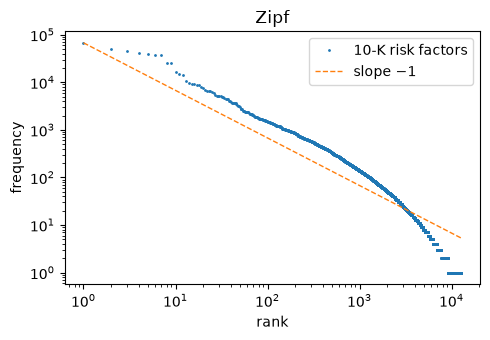

In [4]:
freqs = np.array(sorted(counts.values(), reverse=True))
plt.figure(figsize=(5,3.5))
plt.loglog(np.arange(1, len(freqs)+1), freqs, ".", ms=2, label="10-K risk factors")
plt.loglog([1, len(freqs)], [freqs[0], freqs[0]/len(freqs)], "--", lw=1, label="slope −1")
plt.xlabel("rank"); plt.ylabel("frequency"); plt.legend(); plt.title("Zipf"); plt.tight_layout()

## 2. An n-gram language model

The chain rule says $p(x_1,\dots,x_T)=\prod_t p(x_t\mid x_{<t})$. The n-gram model keeps only the last $n-1$ words of context and **counts**:

$$\hat p(w_t \mid w_{t-1}) = \frac{c(w_{t-1}, w_t)}{c(w_{t-1})}$$

Two practical details: sentence boundaries get a `<s>` / `</s>` token, and unseen words get an `<unk>` token (every word seen only once in training is replaced by `<unk>`, so the model has some `<unk>` mass). Pure counting assigns probability zero to any unseen pair, which makes the test perplexity infinite, so we **interpolate** the trigram, bigram and unigram estimates — the simplest of the smoothing methods that were state of the art until ~2012.

In [5]:
UNK = "<unk>"
vocab = {w for w, c in counts.items() if c > 1}
def prep(toks, n):
    toks = [t if t in vocab else UNK for t in toks]
    return ["<s>"] * (n - 1) + toks + ["</s>"]

class NGramLM:
    def __init__(self, n, lambdas):
        self.n, self.lambdas = n, lambdas          # weights for orders n, n-1, ..., 1
        self.counts = [collections.Counter() for _ in range(n)]      # counts[k]: (k+1)-gram
        self.ctx    = [collections.Counter() for _ in range(n)]      # ctx[k]: k-gram context totals
    def fit(self, sents):
        for s in sents:
            s = prep(s, self.n)
            for i in range(self.n - 1, len(s)):
                for k in range(self.n):
                    self.counts[k][tuple(s[i-k:i+1])] += 1
                    self.ctx[k][tuple(s[i-k:i])] += 1
        self.N = sum(self.ctx[0].values())
        self.vocab_list = [w for (w,) in self.counts[0] if w != "<s>"]
    def prob(self, hist, w):
        p = 0.0
        for k, lam in zip(range(self.n - 1, -1, -1), self.lambdas):
            h = tuple(hist[len(hist)-k:]) if k else ()
            c = self.ctx[k][h] if k else self.N
            p += lam * (self.counts[k][h + (w,)] / c if c else 0.0)
        return p
    def perplexity(self, sents):
        nll, T = 0.0, 0
        for s in sents:
            s = prep(s, self.n)
            for i in range(self.n - 1, len(s)):
                nll -= math.log(self.prob(s[max(0,i-self.n+1):i], s[i]) + 1e-12); T += 1
        return math.exp(nll / T)
    def sample(self, max_len=40, temperature=1.0):
        out = ["<s>"] * (self.n - 1)
        for _ in range(max_len):
            hist = out[-(self.n-1):] if self.n > 1 else []
            cand = self.vocab_list
            ps = np.array([self.prob(hist, w) for w in cand]) ** (1/temperature)
            w = np.random.choice(cand, p=ps/ps.sum())
            if w == "</s>": break
            out.append(w)
        return " ".join(out[self.n-1:])

models = {
    "unigram": NGramLM(1, [1.0]),
    "bigram":  NGramLM(2, [0.8, 0.2]),
    "trigram": NGramLM(3, [0.6, 0.3, 0.1]),
}
for name, m in models.items():
    m.fit(train_tok)
    print(f"{name:8s} test perplexity = {m.perplexity(test_tok):7.1f}")

unigram  test perplexity =   468.2


bigram   test perplexity =    71.0


trigram  test perplexity =    41.4


Perplexity is the *effective number of equally likely words* the model is choosing among at each step. Uniform over the vocabulary would be $V\approx$ 13,000; the trigram gets it down to about 40 — and GPT-2, below, to about 33 with no filings in its training data. Now look at what the model has actually learned — and what it has not.

In [6]:
for name in ["bigram", "trigram"]:
    print(f"--- {name} samples ---")
    for _ in range(3):
        print(" ", models[name].sample())

--- bigram samples ---


  from non - 19 is difficult to persons employed by end - 19 ; and a as percentage conditions include uneven periods . the impact on our bylaws , including the european union ( and adversely affect the marketplaces to


  in have annual or fail to the loss of the increased costs connected to the financial markets .


  we may be materially and to meet offerings and trade . proceeds in detail below expected of to , we may impact
--- trigram samples ---


  our efforts to develop , and declines on or before the anticipated future to further and services and healthcare providers have upgraded their data networks in our closed block policies of the driftwood project generally one foreign regulatory authorities to


  despite the implementation of our stockholders could subject us to property , such , financial condition , and lng prices have declined <unk> , and his ; loads .
  these limitations as reduce funds available to , among other things key role in our market area may reduce our customers and prospects .


**Locally fluent, globally empty.** Each sample reads like a filing for three or four words at a time, then forgets. Two questions to try:

- Raise `temperature` to 2 and to 0.3 in `sample()`. What changes, and what does not?
- How many of the test set's bigrams never occur in training? (That is the sparsity problem; the interpolation weights are what keep the perplexity finite.)

In [7]:
train_bigrams = set(models["bigram"].counts[1])
test_bigrams  = [tuple(b) for s in test_tok for b in zip(prep(s,2)[:-1], prep(s,2)[1:])]
unseen = sum(b not in train_bigrams for b in test_bigrams)
print(f"test bigrams: {len(test_bigrams):,}; unseen in training: {unseen:,} = {unseen/len(test_bigrams):.1%}")

test bigrams: 113,646; unseen in training: 8,410 = 7.4%

## 3. What a modern model says about a 10-K sentence

GPT-2 (2019, 124M parameters) is the smallest transformer language model people still use. Same object as the n-gram — $p(\text{next token}\mid\text{context})$ — but the context is 1,024 tokens and the "table" is a function. Let's read its predictions on the lecture's sentence, token by token.

Note the tokenizer: it is *subword* (byte-pair encoding). `10-K` becomes three tokens, `EBITDA` three, `Nasdaq` three.

In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
tok = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModelForCausalLM.from_pretrained("gpt2").eval()

for s in ["10-K", "EBITDA", "Nasdaq", "materially adversely affect"]:
    print(f"{s!r:32s} -> {[tok.decode([i]) for i in tok(s).input_ids]}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

'10-K'                           -> ['10', '-', 'K']
'EBITDA'                         -> ['E', 'BIT', 'DA']
'Nasdaq'                         -> ['N', 'as', 'daq']
'materially adversely affect'    -> ['m', 'ater', 'ially', ' adversely', ' affect']


In [9]:
sentence = "Physical climate risks may materially affect our operations and financial results."
ids = tok(sentence, return_tensors="pt").input_ids
with torch.no_grad():
    logp = torch.log_softmax(gpt2(ids).logits[0, :-1], dim=-1)

rows, total = [], 0.0
for t in range(ids.shape[1] - 1):
    nxt = ids[0, t+1].item(); lp = logp[t, nxt].item(); total -= lp
    top3 = [tok.decode([i]) for i in logp[t].topk(3).indices.tolist()]
    rows.append({"context ends with": tok.decode([ids[0, t].item()]), "actual next": tok.decode([nxt]),
                 "p(actual)": round(math.exp(lp), 3), "bits": round(-lp/math.log(2), 1), "model's top 3": top3})
display(pd.DataFrame(rows))
print(f"average {total/(ids.shape[1]-1):.2f} nats/token  ->  perplexity {math.exp(total/(ids.shape[1]-1)):.1f}")

,context ends with,actual next,p(actual),bits,model's top 3
0,Physical,climate,0.000,14.9,"[\n, ,, .]"
1,climate,risks,0.000,13.6,"[ is, ,, .]"
2,risks,may,0.015,6.1,"[ are, ,, .]"
3,may,materially,0.000,12.8,"[ be, include, also]"
4,materially,affect,0.216,2.2,"[ affect, increase, and]"
5,affect,our,0.036,4.8,"[ the, your, our]"
6,our,operations,0.011,6.5,"[ business, ability, results]"
7,operations,and,0.367,1.4,"[ and, ., ,]"
8,and,financial,0.187,2.4,"[ results, financial, operating]"
9,financial,results,0.350,1.5,"[ condition, results, performance]"


average 4.22 nats/token  ->  perplexity 68.2


Read a few rows. `materially → affect` is a legal-English collocation the model has learned (22 %). `Physical → climate` is nearly impossible for a 2019 general-web model — a model trained on filings would put real mass there. That gap is what domain adaptation (Lecture 2) is about.

**Temperature** rescales the logits before the softmax. The *ranking* never changes; only the gaps do.

In [10]:
i = [k for k in range(ids.shape[1]) if tok.decode([ids[0,k].item()]) == " may"][0]
with torch.no_grad():
    z = gpt2(ids[:, :i+1]).logits[0, -1]
for T in [0.5, 1.0, 2.0]:
    p = torch.softmax(z / T, -1); top = p.topk(5)
    print(f"T={T}: ", [(tok.decode([j]), round(v, 3)) for v, j in zip(top.values.tolist(), top.indices.tolist())])

T=0.5:  [(' be', 0.682), (' include', 0.191), (' also', 0.072), (' vary', 0.017), (' not', 0.01)]
T=1.0:  [(' be', 0.272), (' include', 0.144), (' also', 0.088), (' vary', 0.043), (' not', 0.034)]
T=2.0:  [(' be', 0.025), (' include', 0.018), (' also', 0.014), (' vary', 0.01), (' not', 0.009)]


Now the same perplexity number for GPT-2 on **our** test sentences, so it is comparable with the n-gram models above. (Different tokenizers, so the comparison is only rough — that caveat is real and worth remembering whenever you see perplexities compared across models.)

In [11]:
def gpt2_ppl(sents, max_n=200):
    nll, T = 0.0, 0
    with torch.no_grad():
        for s in sents[:max_n]:
            ids = tok(s, return_tensors="pt", truncation=True, max_length=256).input_ids
            lp = torch.log_softmax(gpt2(ids).logits[0, :-1], -1)
            nll -= lp[torch.arange(ids.shape[1]-1), ids[0, 1:]].sum().item(); T += ids.shape[1] - 1
    return math.exp(nll / T)
print(f"GPT-2 perplexity on 200 held-out risk-factor sentences: {gpt2_ppl(test_sents):.1f}")

GPT-2 perplexity on 200 held-out risk-factor sentences: 32.9


## 4. The rookie mistake: raw embeddings all look alike

Take BERT, mean-pool its last layer over a sentence, and compute cosine similarities. Every pair scores 0.9-something. Nearest neighbours are noise. This is **anisotropy**: the training objective pushes all hidden states into a narrow cone. Diagnose it in ten seconds; then two fixes.

In [12]:
from transformers import AutoModel
btok = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased").eval()

def bert_embed(sents, layer=-1, bs=32):
    out = []
    with torch.no_grad():
        for i in range(0, len(sents), bs):
            enc = btok(sents[i:i+bs], padding=True, truncation=True, max_length=64, return_tensors="pt")
            hs = bert(**enc, output_hidden_states=True).hidden_states[layer]
            m = enc.attention_mask.unsqueeze(-1)
            out.append(((hs * m).sum(1) / m.sum(1)).numpy())
    return np.vstack(out)

sample = random.sample(test_sents, 400)
E_bert = bert_embed(sample)

def cos(A, B=None):
    A = A / np.linalg.norm(A, axis=1, keepdims=True)
    B = A if B is None else B / np.linalg.norm(B, axis=1, keepdims=True)
    return A @ B.T

S = cos(E_bert); off = S[np.triu_indices(len(sample), 1)]
print(f"raw BERT, mean-pooled last layer: cosine between RANDOM sentence pairs = {off.mean():.3f} ± {off.std():.3f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


raw BERT, mean-pooled last layer: cosine between RANDOM sentence pairs = 0.717 ± 0.072


That number should be close to 0 for unrelated sentences. It is ~0.7–0.8 for raw BERT, and would be higher still for a decoder like GPT-2. Compare with a model that was **contrastively fine-tuned** (Sentence-BERT recipe) — same architecture family, different training objective:

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence-BERT (contrastive): cosine between RANDOM sentence pairs = 0.218 ± 0.130


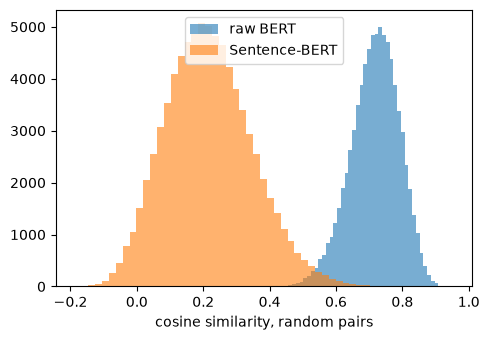

In [13]:
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
E_sbert = sbert.encode(sample, batch_size=64, normalize_embeddings=True)
S2 = cos(E_sbert); off2 = S2[np.triu_indices(len(sample), 1)]
print(f"Sentence-BERT (contrastive): cosine between RANDOM sentence pairs = {off2.mean():.3f} ± {off2.std():.3f}")

plt.figure(figsize=(5,3.5))
plt.hist(off, bins=50, alpha=.6, label="raw BERT"); plt.hist(off2, bins=50, alpha=.6, label="Sentence-BERT")
plt.xlabel("cosine similarity, random pairs"); plt.legend(); plt.tight_layout()

**Fix 1 — all-but-the-top** (Mu & Viswanath 2018): subtract the mean vector and remove the top few principal components. Two lines; often enough.

In [14]:
def all_but_the_top(E, k=2):
    E = E - E.mean(0)
    U, s, Vt = np.linalg.svd(E, full_matrices=False)
    return E - (E @ Vt[:k].T) @ Vt[:k]

E_fix = all_but_the_top(E_bert, k=2)
off3 = cos(E_fix)[np.triu_indices(len(sample), 1)]
print(f"raw BERT after mean-centering + removing 2 PCs: random-pair cosine = {off3.mean():.3f} ± {off3.std():.3f}")

raw BERT after mean-centering + removing 2 PCs: random-pair cosine = -0.002 ± 0.134


**Does it matter for anything you would do?** Nearest neighbours. Pick a sentence and look at its closest three under each representation.

In [15]:
q = [s for s in sample if "climate" in s.lower() or "weather" in s.lower()]
q = q[0] if q else sample[0]
qi = sample.index(q)
print("QUERY:", q, "\n")
for name, M in [("raw BERT", S), ("BERT, all-but-the-top", cos(E_fix)), ("Sentence-BERT", S2)]:
    nn = np.argsort(-M[qi])[1:4]
    print(f"--- {name} ---")
    for j in nn: print(f"  {M[qi, j]:.2f}  {sample[j][:130]}")
    print()

QUERY: The North America and Brazil agricultural sector can be affected by a number of factors, including weather conditions, field conditions (particularly during periods of traditionally high plant nutrition application), government policies, tariffs and import and export markets. 

--- raw BERT ---
  0.88  Agricultural commodity production and trade flows are significantly affected by government policies and regulations.
  0.87  Our sales seasonality is affected by a number of factors, including global and regional economic conditions as well as the PC mark
  0.82  Our ability to secure sufficient equipment or other transportation services may be affected by many risks beyond our control, incl

--- BERT, all-but-the-top ---
  0.60  Agricultural commodity production and trade flows are significantly affected by government policies and regulations.
  0.50  Our sales seasonality is affected by a number of factors, including global and regional economic conditions as well as the PC mark

### Take-aways

- The n-gram and GPT-2 estimate the **same object**, $p(\text{next token}\mid\text{context})$, and are scored by the same number, perplexity. Only the context map differs.
- Subword tokenization is why token counts, prices and context limits depend on the tokenizer, and why numbers and tickers fragment.
- **Never use raw pooled hidden states for cosine similarity.** Check the random-pair cosine first; if it is far from zero, whiten / remove the top components, or use a contrastively trained embedding model.

Next notebook: `babymodels` — the neural language model, word2vec-style pooling and one transformer block, trained from scratch in 18 seconds.